## Baseline Model: Logistic Regression

### Part 1

##### Importing necessary libraries and constant variables

In [1]:
# custom imports
from src.utils.data_fetch import DataLoader
from src.visualisations.viz_model import plot_confusion_matrix

# sklearn libraries
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# other eseential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# various scoring metrics
from sklearn.metrics import (classification_report, accuracy_score,
                             recall_score, precision_score,
                             f1_score, roc_auc_score)

# for hyperparameter tuning
import optuna

# used for exporting the final logistic regression model
# and evaluation results.
from pathlib import Path
import joblib
# export path for the final logistic regression model:
project_root = Path.cwd().parent.parent.resolve()
export_dir = project_root / 'models' / 'logistic_regression'
#commented: export_dir.mkdir(parents=True, exist_ok=True)

SEED = 1234

/Users/vassilistsoubris/PycharmProjects/ds207_final_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Functions to be used for model creation, evaluation and visualization

*Note: Some of the functions defined below are also added to **src.utils.model_eval.evaluation** for later use in other notebooks.*

In [2]:
def fit_log_regression(Xtrain, ytrain, Xval,
                       chosen_features_list = None,
                       seed = SEED,
                       c = None,
                       normalise_data = False):
    """
    Fits a logistic regression model on the selected features from the training dataset and evaluates
    it on both the training and validation datasets. A preprocessing pipeline is used
    to normalise numeric features before fitting the logistic regression model when requested.
    The regularization strength is configurable through the parameter `c`.

    :param Xtrain: The training dataset as a DataFrame.
    :type Xtrain: pandas.DataFrame
    :param ytrain: The target labels corresponding to the training dataset.
    :type ytrain: pandas.DataFrame
    :param Xval: The validation dataset as a DataFrame.
    :type Xval: pandas.DataFrame
    :param chosen_features_list: A list of selected feature names to be used as predictors.
    :type chosen_features_list: list[str]
    :param seed: The random seed for reproducibility when fitting the logistic regression model.
        Defaults to a predefined constant value (SEED).
    :type seed: int
    :param c: Regularization parameter for the logistic regression model. Controls the inverse of
        regularization strength (higher values reduce regularization and vice versa). Defaults to 1.0.
    :type c: float, optional
    :param normalise_data: Whether to normalise the selected features before fitting the model.
        Defaults to True.
    :type normalise_data: bool
    :return: A tuple containing the fitted logistic regression pipeline, predicted labels for the
        training dataset (`y_pred_train`), and predicted labels for the validation dataset (`y_pred_validation`).
    :rtype: tuple[sklearn.pipeline.Pipeline, numpy.ndarray, numpy.ndarray]
    """

    if c is None:
        # the default value of C in LogisticRegression() is 1.0
        # - bigger C = smaller regularization
        # - smaller C = bigger regularization
        c = 1.0
    # if no features are selected, use all features:
    if chosen_features_list is None:
        chosen_features_list = Xtrain.columns.to_list()

    # creating a simple logistic regression model pipeline
    # based on the features selected (inside the list):

    # initializing the pipeline steps as an empty list
    steps = []
    # if normalisation is required,
    # add the scaler step to the pipeline
    if normalise_data:
        steps.append(('scaler', StandardScaler()))
    # add the logistic regression step to the pipeline and its parameters
    steps.append(('lr', LogisticRegression(max_iter = 500,
                                           C = c,
                                           class_weight = 'balanced',
                                           solver = 'liblinear', # or 'lbfgs',
                                           random_state = seed)))
    # create the pipeline
    model = Pipeline(steps=steps)
    # fit the pipeline to X-train and y-train data
    model.fit( Xtrain[chosen_features_list], ytrain['readmitted'])

    # y-pred: TRAIN
    y_pred_train = model.predict(X= Xtrain[chosen_features_list])
    # y-pred: VALIDATION
    y_pred_validation = model.predict(X= Xval[chosen_features_list])

    return model, y_pred_train, y_pred_validation

In [3]:
## -> added to src.utils.model_eval.evaluation
def evaluate_predictions(true_values, predictions, print_class_report = True):
    """
    Evaluate the performance of classification predictions based on the given true
    values. This function calculates recall, precision, F1-score, and optionally
    prints the classification report.

    The metrics are computed using the 'readmitted' column of the `true_values` data
    and the predicted values provided. This function can be used to assess the
    effectiveness of a classification model.

    :param true_values: A DataFrame containing the actual class labels. The column
        'readmitted' is used as the target data.
    :type true_values: pandas.DataFrame

    :param predictions: The predicted labels that correspond to the 'readmitted' target
        column in `true_values`.
    :type predictions: ndarray or list

    :param print_class_report: A boolean flag indicating whether to print the detailed
        classification report. Defaults to True.
    :type print_class_report: bool

    :return: A tuple containing the following calculated metrics:
        - recall: The recall score of the predictions.
        - precision: The precision score of the predictions.
        - f1: The F1-score of the predictions.
        - acc: The accuracy score of the predictions.
        - cl_report: The full classification report as a string.
    :rtype: tuple[float, float, float, str]
    """

    ##  sklearn-metrics ##
    # recall: TP / (TP + FN)
    recall = recall_score(
        y_true= true_values['readmitted'],
        y_pred= predictions)
    # precision: TP / (TP + FP)
    precision = precision_score(
        y_true= true_values['readmitted'],
        y_pred= predictions)
    # F1-score:
    # 2 * (precision * recall) / (precision + recall)
    f1 = f1_score(
        y_true= true_values['readmitted'],
        y_pred= predictions)
    # accuracy: (TP + TN) / (TP + TN + FP + FN)
    acc = accuracy_score(
        y_true= true_values['readmitted'],
        y_pred= predictions
    )
    # Classification report:
    cl_report = classification_report(
        y_true= true_values['readmitted'],
        y_pred= predictions,
        zero_division=0
    )


    if print_class_report:
        print(cl_report)

    return recall, precision, f1, acc, cl_report

#### Function to be used for exporting results of final model

*Note: the function defined below are also added to **src.utils.model_eval.evaluation** for later use in other notebooks.*

In [4]:
def build_results_row(split,
                      true_values,
                      predictions,
                      features,
                      best_model,
                      best_parameters,
                      model_name='logistic_regression'
                      ):

    y_true = true_values['readmitted']
    y_proba = best_model.predict_proba(features)[:, 1]

    return {
        'model': model_name,
        'split': split,
        'n_rows': len(y_true),
        'best_C': best_parameters,
        'accuracy': accuracy_score(y_true, predictions),
        'recall': recall_score(y_true, predictions),
        'precision': precision_score(y_true, predictions),
        'f1': f1_score(y_true, predictions),
        'roc_auc': roc_auc_score(y_true, y_proba),
    }

##### Downloading the final processed data (version: "raw").
The "raw" version contains some engineered features (new categorical features) but not the one-hot/label encoded version of the categorical features.

In [5]:
df_Xtrain, df_Xval, df_Xtest, df_ytrain, df_yval, df_ytest = \
    DataLoader().fetch_data(version = 'final_raw')

Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/raw/X_train_mini.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/raw/X_val.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/raw/X_test.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/raw/y_train_mini.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/raw/y_val.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/raw/y_test.csv 
Data imported succesfully from paths


### Part 2 - Model Creation

Choosing some features (numeric only) for a draft Logistic Regression model:

In [6]:
chosen_features = \
['time_in_hospital', 'num_lab_procedures', 'num_procedures',
 'num_medications',  'number_outpatient',  'number_emergency',
 'number_inpatient', 'number_diagnoses']

Creating a simple logistic regression model pipeline based on the features selected above:

In [7]:
lr, y_pred_tr, y_pred_vl = \
    fit_log_regression(Xtrain = df_Xtrain,
                       ytrain = df_ytrain,
                       Xval = df_Xval,
                       chosen_features_list = chosen_features,
                       seed = SEED,
                       c = None,
                       normalise_data = True)
lr

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work 

### Initial Classification Report: Training Set

              precision    recall  f1-score   support

           0       0.62      0.75      0.68     31515
           1       0.63      0.47      0.54     28090

    accuracy                           0.62     59605
   macro avg       0.62      0.61      0.61     59605
weighted avg       0.62      0.62      0.61     59605



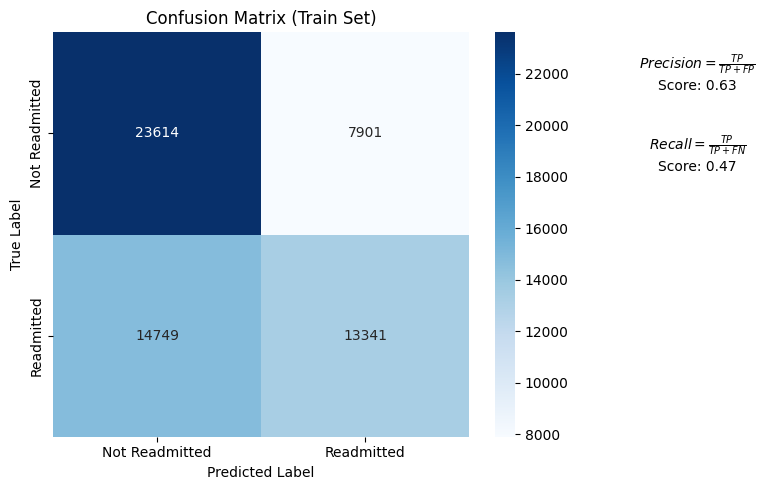

In [8]:
recall_tr, precision_tr, f1_tr, _ , cl_report_tr = \
    evaluate_predictions(true_values = df_ytrain,
                         predictions = y_pred_tr,
                         print_class_report = True)

results_cm_train = \
plot_confusion_matrix(df_ytrain['readmitted'],
                      y_pred_tr,
                      class_names= ['Not Readmitted', 'Readmitted'],
                      fig_size= (8,5),
                      title= 'Confusion Matrix (Train Set)'
                      )

### Initial Classification Report: Validation Set

              precision    recall  f1-score   support

           0       0.62      0.76      0.68     10506
           1       0.64      0.48      0.55      9363

    accuracy                           0.62     19869
   macro avg       0.63      0.62      0.61     19869
weighted avg       0.63      0.62      0.62     19869



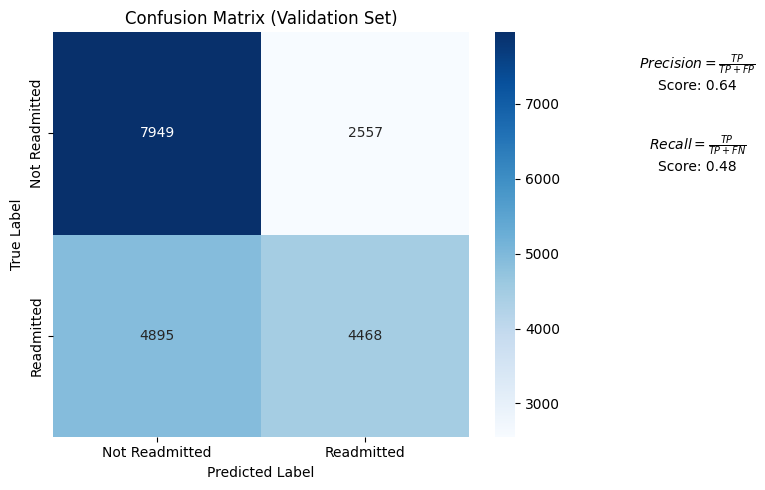

In [9]:
recall_vl, precision_vl, f1_vl, _ , cl_report_vl = \
    evaluate_predictions(true_values = df_yval,
                         predictions = y_pred_vl,
                         print_class_report = True)

# confusion matrix
results_cm_val = \
    plot_confusion_matrix(df_yval['readmitted'],
                      y_pred_vl,
                      class_names= ['Not Readmitted', 'Readmitted'],
                      fig_size= (8,5),
                      title= 'Confusion Matrix (Validation Set)'
                      )

## Adding more features to the model

I will have to transform the categorical features to OH-encoded in order to proceed. In other words, I could use the already processed dataset available through DataLoader class.

In [10]:
df_Xtrain, df_Xval, df_Xtest, df_ytrain, df_yval, df_ytest = \
    DataLoader().fetch_data(version = 'final_onehot')

Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/X_train_mini.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/X_val.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/X_test.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/y_train_mini.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/y_val.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/y_test.csv 
Data imported succesfully from paths


Dropping identifier columns:

In [11]:
# Drop identifier columns
id_cols = [c for c in df_Xtrain.columns if 'encounter_id' in c or 'patient_nbr' in c]
X_train_lr = df_Xtrain.drop(columns=id_cols)
X_val_lr = df_Xval.drop(columns=id_cols)
X_test_lr = df_Xtest.drop(columns=id_cols)

Creating the pipeline:

In [12]:
lr, y_pred_tr, y_pred_vl = \
    fit_log_regression(Xtrain = X_train_lr, # changed from df_Xtrain
                       ytrain = df_ytrain,
                       Xval = X_val_lr, # changed from df_Xval
                       chosen_features_list = None, # choose all features
                       seed = SEED,
                       c = None,
                       normalise_data = False) # not needed when using the OH version
lr

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpe

Evaluating the model (on train and validation sets):

---> Training set Evaluation

              precision    recall  f1-score   support

           0       0.64      0.68      0.66     31515
           1       0.61      0.56      0.59     28090

    accuracy                           0.63     59605
   macro avg       0.62      0.62      0.62     59605
weighted avg       0.63      0.63      0.62     59605



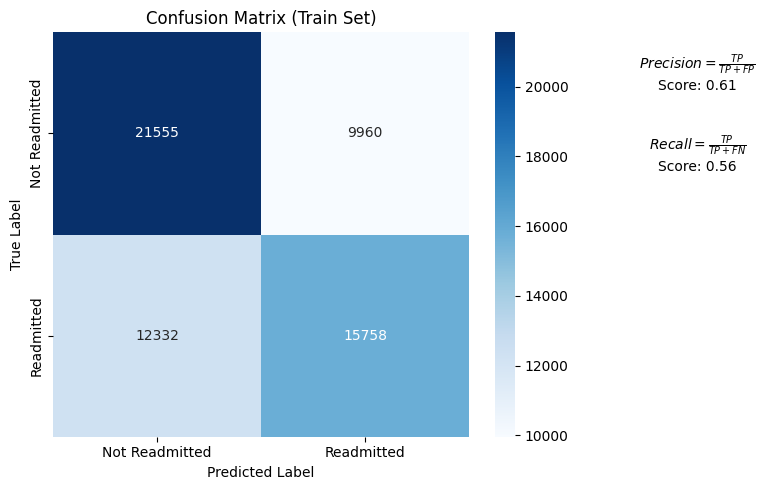

---> Validation set Evaluation

              precision    recall  f1-score   support

           0       0.64      0.70      0.67     10506
           1       0.62      0.56      0.59      9363

    accuracy                           0.63     19869
   macro avg       0.63      0.63      0.63     19869
weighted avg       0.63      0.63      0.63     19869



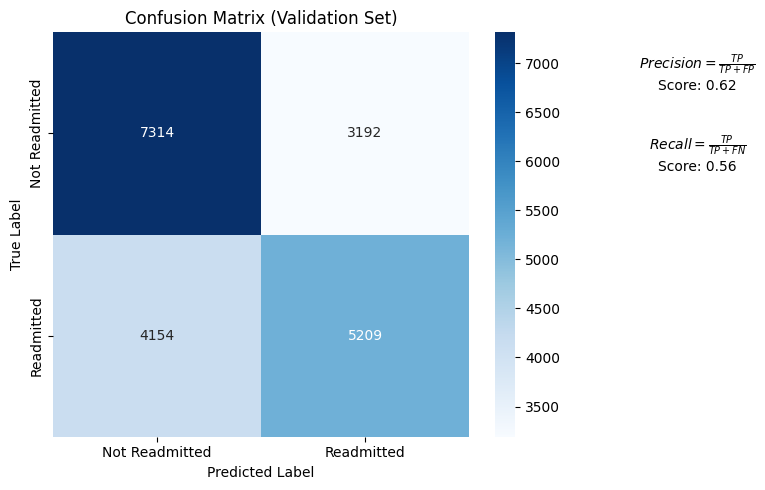

In [13]:
print(f'---> Training set Evaluation\n')

recall_tr, precision_tr, f1_tr, _ , cl_report_tr = \
    evaluate_predictions(true_values = df_ytrain,
                         predictions = y_pred_tr,
                         print_class_report = True)

# confusion matrix
results_cm_val = \
    plot_confusion_matrix(df_ytrain['readmitted'],
                      y_pred_tr,
                      class_names= ['Not Readmitted', 'Readmitted'],
                      fig_size= (8,5),
                      title= 'Confusion Matrix (Train Set)'
                      )

print(f'---> Validation set Evaluation\n')


recall_vl, precision_vl, f1_vl, _, cl_report_vl = \
    evaluate_predictions(true_values = df_yval,
                         predictions = y_pred_vl,
                         print_class_report = True)

# confusion matrix
results_cm_val = \
    plot_confusion_matrix(df_yval['readmitted'],
                      y_pred_vl,
                      class_names= ['Not Readmitted', 'Readmitted'],
                      fig_size= (8,5),
                      title= 'Confusion Matrix (Validation Set)'
                      )

The recall in validation set is 0.56 (for 'readmitted' values), which is still a low score.

### Part 3 - Choosing the best hyperparameter C using Optuna

- Higher C = Less regularization = Model fits training data more closely (allows more complex decision boundaries)
- Lower C = More regularization = Simpler model (prevents overfitting)

In [14]:
# 1. Define an objective function to be maximized.
def objective(trial,
              X_train = X_train_lr,
              X_val = X_val_lr,
              ytrain = df_ytrain,
              yval = df_yval,
              ):

    # 2. Suggest values for the hyperparameters using a trial object.
    # equivalent to np.logspace(-1.2, 1):
    # range:  0.0631 to 100.0
    lreg_c = trial.suggest_float('lreg_c', 10 ** -1.2, 10 ** 2, log= True)

    # logistic regression model and
    # its predictions (train and validation sets):
    classifier, y_pred_tr, y_pred_vl = \
    fit_log_regression(Xtrain = X_train,
                       ytrain = ytrain,
                       Xval = X_val,
                       seed = SEED,
                       c = lreg_c,
                       normalise_data = False)

    ## DO NOT USE THE THRESHOLD AS A HYPERPARAMETER in trial
    # setting the decision threshold of LogisticRegression
    # as a hyperparameter:
    # threshold = trial.suggest_float('threshold', 0.2, 0.7, step = 0.1)
    # y_proba_vl = lr.predict_proba(X_val)[:, 1]
    # y_pred_vl = (y_proba_vl >= threshold).astype(int)

    # training set:
    recall_tr, _, _, acc_tr, _ = \
    evaluate_predictions(true_values = ytrain,
                         predictions = y_pred_tr,
                         print_class_report = False)

    # validation set:
    recall_vl, _, _, acc_vl , _ = \
    evaluate_predictions(true_values = yval,
                         predictions = y_pred_vl,
                         print_class_report = False)

    # If train accuracy greater than validation accuracy, C is too high
    # could also be implemented with recall metric
    if acc_tr - acc_vl > 0.10:  # >10% gap suggests overfitting
        print(f"Warning: Possible overfitting with C={lreg_c}")

    # return the objective value (recall score in validation set)
    return recall_vl

In [15]:
# 3. Create a study object and optimize the objective function.
study = optuna.create_study(direction='maximize')
study.optimize(objective,
               n_trials= 150,
               timeout= 600,
               n_jobs= -1)

[I 2026-07-10 10:20:02,182] A new study created in memory with name: no-name-0ff297ca-9163-4ec3-9bf0-a9a80f5f1979
[I 2026-07-10 10:20:09,144] Trial 0 finished with value: 0.5548435330556446 and parameters: {'lreg_c': 0.08591582087131405}. Best is trial 0 with value: 0.5548435330556446.
[I 2026-07-10 10:20:11,374] Trial 10 finished with value: 0.5552707465555912 and parameters: {'lreg_c': 0.13305704589114922}. Best is trial 10 with value: 0.5552707465555912.
[I 2026-07-10 10:20:11,667] Trial 2 finished with value: 0.5552707465555912 and parameters: {'lreg_c': 0.14146768796570264}. Best is trial 10 with value: 0.5552707465555912.
[I 2026-07-10 10:20:12,450] Trial 8 finished with value: 0.5554843533055644 and parameters: {'lreg_c': 0.26383436251565423}. Best is trial 8 with value: 0.5554843533055644.
[I 2026-07-10 10:20:15,694] Trial 3 finished with value: 0.5560183701804977 and parameters: {'lreg_c': 0.3404877056514759}. Best is trial 3 with value: 0.5560183701804977.
[I 2026-07-10 10:20

In [16]:
print(study.best_trial)

FrozenTrial(number=25, state=<TrialState.COMPLETE: 1>, values=[0.556872797180391], datetime_start=datetime.datetime(2026, 7, 10, 10, 20, 37, 571881), datetime_complete=datetime.datetime(2026, 7, 10, 10, 21, 12, 494883), params={'lreg_c': 21.707419172195543}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'lreg_c': FloatDistribution(high=100.0, log=True, low=0.06309573444801933, step=None)}, trial_id=25, value=None)


In [17]:
best_C = study.best_params['lreg_c']
print(f'Best C value: {best_C}')

Best C value: 21.707419172195543


### Part 4 - Re-train the model with the best hyperparameter value and test it on unseen data

Validation set evaluation:
              precision    recall  f1-score   support

           0       0.64      0.70      0.67     10506
           1       0.62      0.56      0.59      9363

    accuracy                           0.63     19869
   macro avg       0.63      0.63      0.63     19869
weighted avg       0.63      0.63      0.63     19869



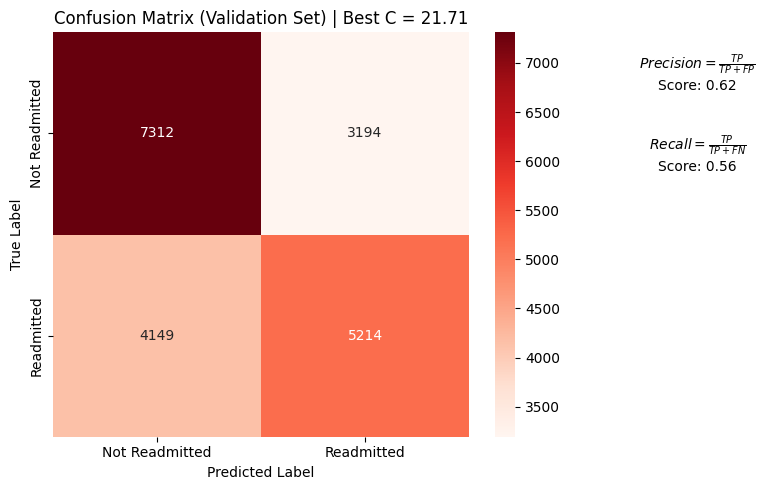

In [19]:
# best logistic regression model and
# its predictions (train and validation sets):
best_lr, y_pred_tr, y_pred_vl = \
fit_log_regression(Xtrain = X_train_lr,
                       ytrain = df_ytrain,
                       Xval = X_val_lr,
                       seed = SEED,
                       c = best_C, # using best C value (hyperparameter)
                       normalise_data = False)

## DO NOT USE THE THRESHOLD AS A HYPERPARAMETER in trial
# threshold = study.best_params['threshold']
# y_proba_vl = best_lr.predict_proba(X_val_lr)[:, 1]
# y_pred_vl = (y_proba_vl >= threshold).astype(int)

print('Validation set evaluation:')
# validation set metrics:
recall_vl, precision_vl, f1_vl, _, cl_report_vl = \
    evaluate_predictions(true_values = df_yval,
                         predictions = y_pred_vl,
                         print_class_report = True)

# confusion matrix-validation set
results_cm_val = \
    plot_confusion_matrix(df_yval['readmitted'],
                      y_pred_vl,
                      class_names= ['Not Readmitted', 'Readmitted'],
                      fig_size= (8,5),
                      colour_map= 'Reds',
                      title= 'Confusion Matrix (Validation Set) | Best C = {:.2f}'.format(best_C)
                      )

In [20]:
from optuna.visualization import plot_slice
# Objective value is the Recall score in the validation set.
# lreg_c is the hyperparameter value used in optuna trial.
plot_slice(study)

#### **Export model and results:**

In [27]:
# model path:
model_path = export_dir / 'logistic_regression_model.joblib'
print(model_path)

/Users/vassilistsoubris/PycharmProjects/ds207_final_project/models/logistic_regression/logistic_regression_model.joblib


In [28]:
# export model
joblib.dump(best_lr, model_path)

['/Users/vassilistsoubris/PycharmProjects/ds207_final_project/models/logistic_regression/logistic_regression_model.joblib']

In [29]:
# predictions on the test set
# currently I do not use the test set,
# since we are not using the test set for evaluation
#commented: y_pred_ts = best_lr.predict(X=X_test_lr)

# summing up results:
results_df = pd.DataFrame([
    build_results_row('train', df_ytrain, y_pred_tr, X_train_lr,
                      best_parameters = study.best_params,  #dictionary
                      best_model = best_lr),
    build_results_row('validation', df_yval, y_pred_vl, X_val_lr,
                      best_parameters = study.best_params,  #dictionary
                      best_model = best_lr),
    # commented: build_results_row('test', df_ytest, y_pred_ts, X_test_lr, best_model = best_lr),
])

results_df

,model,split,n_rows,best_C,accuracy,recall,precision,f1,roc_auc
0,logistic_regression,train,59605,{'lreg_c': 21.707419172195543},0.625937,0.560983,0.612627,0.585669,0.673388
1,logistic_regression,validation,19869,{'lreg_c': 21.707419172195543},0.630429,0.556873,0.620124,0.586799,0.676442


In [30]:
results_path = export_dir / 'logistic_regression_results.csv'
results_df.to_csv(results_path, index=False)

#### Test set (unseen data) evaluation

Test set evaluation:
              precision    recall  f1-score   support

           0       0.64      0.69      0.66     10506
           1       0.62      0.55      0.58      9363

    accuracy                           0.63     19869
   macro avg       0.63      0.62      0.62     19869
weighted avg       0.63      0.63      0.63     19869



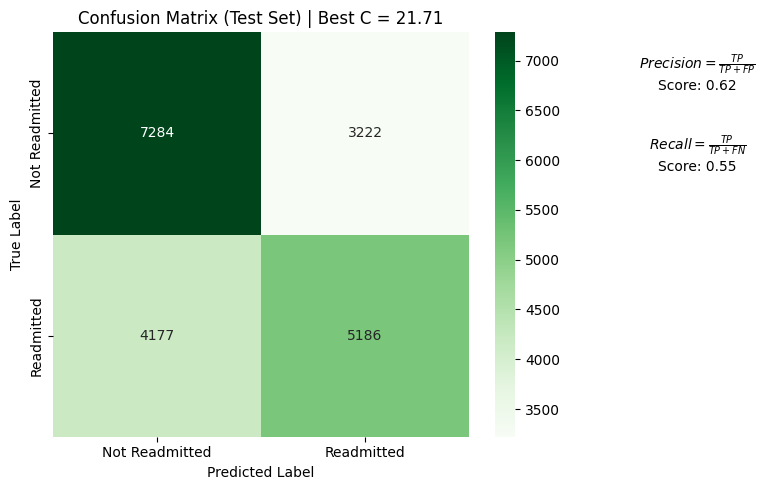

In [31]:
# use the best model to make predictions on the test set (unseen data)
y_pred_ts = best_lr.predict(X = X_test_lr)

print('Test set evaluation:')
# test set metrics:
recall_ts, _, _, _, _ = \
    evaluate_predictions(true_values = df_ytest,
                         predictions = y_pred_ts,
                         print_class_report = True)

# confusion matrix-validation set
results_cm_test = \
    plot_confusion_matrix(df_ytest['readmitted'],
                      y_pred_ts, #test set predictions
                      class_names= ['Not Readmitted', 'Readmitted'],
                      fig_size= (8,5),
                      title= 'Confusion Matrix (Test Set) | Best C = {:.2f}'.format(best_C),
                      colour_map = 'Greens'
                      )